In [1]:
import pdblp
import pandas as pd
import numpy as np
from xbbg import blp
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from pandas.plotting import table
from PIL import Image
import statsmodels.api as sm
from scipy.stats import zscore
from datetime import datetime, timedelta


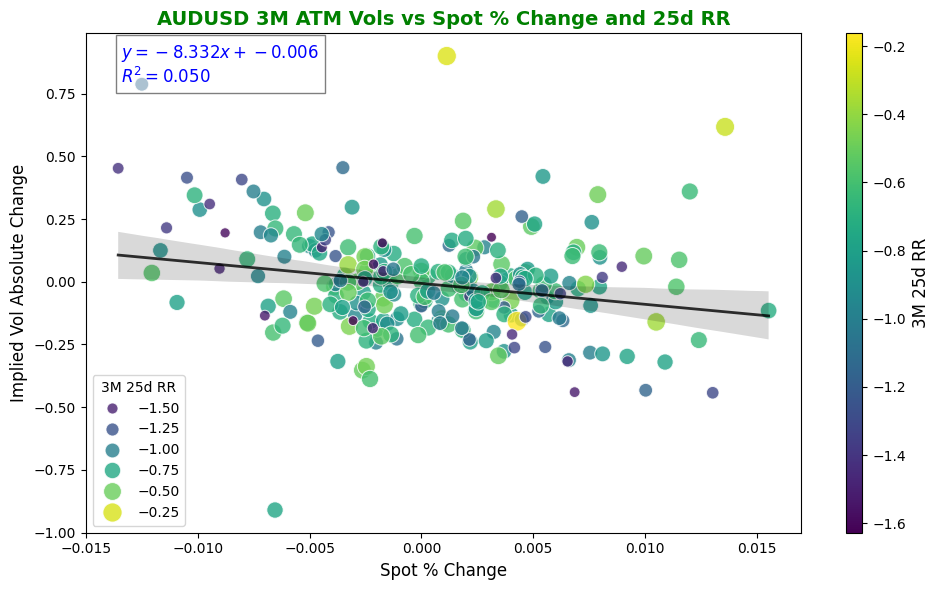

In [2]:
ccy = 'AUDUSD'
tenor = '3M'
days = 365


start_date = (datetime.today() - timedelta(days=(days))).strftime('%Y-%m-%d')
end_date = datetime.today().strftime('%Y-%m-%d')
tickers = [ f'{ccy}V{tenor} Curncy',  
            f'{ccy}25R{tenor} Curncy',     
            f'{ccy} Curncy']

data_IV = blp.bdh(
    tickers=tickers,
    flds=['PX_LAST'],
    start_date=start_date,
    end_date=end_date)

data_IV.columns = [ f'{ccy} V{tenor}', f'{ccy} {tenor}25R', f'{ccy} Spot']
spot_prices = data_IV[f'{ccy} Spot'] 
spot_pct_change = spot_prices.pct_change()
data_IV[f'{ccy} Spot Change']  = spot_pct_change
data_IV[f'{ccy} V{tenor} Abs Change'] = data_IV[f'{ccy} V{tenor}'].diff()

plot_data = pd.DataFrame({
    'Spot % Change': data_IV[f'{ccy} Spot Change'],
    'Implied Vol Absolute Change': data_IV[f'{ccy} V{tenor} Abs Change'],
    f'{tenor} 25d RR': data_IV[f'{ccy} {tenor}25R']}).dropna() 






X = plot_data['Spot % Change']
y = plot_data['Implied Vol Absolute Change']
X = sm.add_constant(X)  
model = sm.OLS(y, X).fit()
intercept, slope = model.params
r_squared = model.rsquared

plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=plot_data,
    x='Spot % Change',
    y='Implied Vol Absolute Change',
    hue=f'{tenor} 25d RR',  
    palette='viridis',
    size=f'{tenor} 25d RR',  
    sizes=(50, 200),
    alpha=0.8)
sns.regplot(
    data=plot_data,
    x='Spot % Change',
    y='Implied Vol Absolute Change',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2, 'alpha': 0.8})
equation_text = f"$y = {slope:.3f}x + {intercept:.3f}$\n$R^2 = {r_squared:.3f}$"
plt.text(
    0.05, 0.9, equation_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    color="blue",
    bbox=dict(facecolor='white', alpha=0.5))
plt.title(f'{ccy} {tenor} ATM Vols vs Spot % Change and 25d RR', fontsize=14, fontweight='bold', color='green')
plt.xlabel('Spot % Change', fontsize=12)
plt.ylabel('Implied Vol Absolute Change', fontsize=12)
norm = plt.Normalize(plot_data[f'{tenor} 25d RR'].min(), plot_data[f'{tenor} 25d RR'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca(), aspect=30)
cbar.set_label(f'{tenor} 25d RR', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
data_IV

,AUDUSD V3M,AUDUSD 3M25R,AUDUSD Spot,AUDUSD Spot Change,AUDUSD V3M Abs Change
2024-12-18,10.1300,-1.0575,0.6218,NaN,NaN
2024-12-19,10.3800,-1.1400,0.6239,0.003377,0.2500
2024-12-20,10.5900,-1.1250,0.6251,0.001923,0.2100
2024-12-23,10.6250,-1.1450,0.6249,-0.000320,0.0350
2024-12-24,10.6425,-1.1400,0.6237,-0.001920,0.0175
...,...,...,...,...,...
2025-12-12,8.3575,-0.6900,0.6652,-0.001801,0.0200
2025-12-15,8.3975,-0.6875,0.6641,-0.001654,0.0400
2025-12-16,8.1875,-0.6750,0.6632,-0.001355,-0.2100
2025-12-17,8.0975,-0.6900,0.6605,-0.004071,-0.0900


In [ ]:
def get_spotVol_RR_data(ccy, tenor, days):
    start_date = (datetime.today() - timedelta(days=days)).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')
    tickers = [
        f'{ccy}V{tenor} Curncy',     # ATM vol
        f'{ccy}25R{tenor} Curncy',   # 25d RR
        f'{ccy} Curncy']
    data_IV = blp.bdh(
        tickers=tickers,
        flds=['PX_LAST'],
        start_date=start_date,
        end_date=end_date)
    if isinstance(data_IV.columns, pd.MultiIndex):
        data_IV.columns = [c[0] if isinstance(c, tuple) else c for c in data_IV.columns]
    data_IV = data_IV.rename(columns={
        f'{ccy}V{tenor} Curncy': f'{ccy} V{tenor}',
        f'{ccy}25R{tenor} Curncy': f'{ccy} {tenor}25R',
        f'{ccy} Curncy': f'{ccy} Spot'})
    spot_prices = data_IV[f'{ccy} Spot']
    data_IV[f'{ccy} Spot Change'] = spot_prices.pct_change()
    data_IV[f'{ccy} V{tenor} Abs Change'] = data_IV[f'{ccy} V{tenor}'].diff()
    return data_IV


In [26]:
ccy   = "AUDUSD"
tenor = "3M"
days  = 365


data_IV = get_spotVol_RR_data(ccy, tenor, days)

In [27]:
vol_series = data_IV[f'{ccy} V{tenor}']
low_q = vol_series.quantile(0.33)
high_q = vol_series.quantile(0.66)

def vol_regime(vol):
    if pd.isna(vol):
        return np.nan
    if vol <= low_q:
        return 'Low Vol'
    elif vol <= high_q:
        return 'Medium Vol'
    else:
        return 'High Vol'

data_IV['Vol Regime'] = vol_series.apply(vol_regime)

In [29]:
plot_data = pd.DataFrame({
    'Spot % Change': data_IV[f'{ccy} Spot Change'],
    'Implied Vol Absolute Change': data_IV[f'{ccy} V{tenor} Abs Change'],
    f'{tenor} 25d RR': data_IV[f'{ccy} {tenor}25R'],
    'Vol Regime': data_IV['Vol Regime'],
    f'{ccy} V{tenor} Level': data_IV[f'{ccy} V{tenor}']
}).dropna()

In [30]:
plot_data

,Spot % Change,Implied Vol Absolute Change,3M 25d RR,Vol Regime,AUDUSD V3M Level
2024-12-19,0.003377,0.2500,-1.1400,High Vol,10.3800
2024-12-20,0.001923,0.2100,-1.1250,High Vol,10.5900
2024-12-23,-0.000320,0.0350,-1.1450,High Vol,10.6250
2024-12-24,-0.001920,0.0175,-1.1400,High Vol,10.6425
2024-12-25,0.000321,0.0525,-1.1400,High Vol,10.6950
...,...,...,...,...,...
2025-12-12,-0.001801,0.0200,-0.6900,Low Vol,8.3575
2025-12-15,-0.001654,0.0400,-0.6875,Low Vol,8.3975
2025-12-16,-0.001355,-0.2100,-0.6750,Low Vol,8.1875
2025-12-17,-0.004071,-0.0900,-0.6900,Low Vol,8.0975


In [33]:
# -----------------------------
# Full-sample regression (for reference)
# -----------------------------
X_full = sm.add_constant(plot_data['Spot % Change'])
y_full = plot_data['Implied Vol Absolute Change']
model_full = sm.OLS(y_full, X_full).fit()

full_stats = pd.Series({
    'Intercept': model_full.params['const'],
    'Slope': model_full.params['Spot % Change'],
    'R2': model_full.rsquared,
    'N': int(model_full.nobs)
}, name='Full Sample')

print("\n=== Full-sample regression ===")
full_stats


=== Full-sample regression ===


Intercept     -0.001044
Slope        -26.047413
R2             0.281963
N            261.000000
Name: Full Sample, dtype: float64

In [34]:
# -----------------------------
# Regime-split regressions
# -----------------------------
regime_order = ['Low Vol', 'Medium Vol', 'High Vol']
results = []

for regime in regime_order:
    subset = plot_data[plot_data['Vol Regime'] == regime]
    if len(subset) < 10:
        # Skip tiny samples
        continue

    X = sm.add_constant(subset['Spot % Change'])
    y = subset['Implied Vol Absolute Change']
    model = sm.OLS(y, X).fit()

    results.append({
        'Regime': regime,
        'Intercept': model.params['const'],
        'Slope': model.params['Spot % Change'],
        'R2': model.rsquared,
        'N': int(model.nobs),
        'Vol_q33': low_q,
        'Vol_q66': high_q,
        'Vol_mean_in_regime': subset[f'{ccy} V{tenor} Level'].mean()
    })

regime_results = pd.DataFrame(results).set_index('Regime')

print("\n=== Regime-split regressions (ATM vol level regimes) ===")
print(regime_results[['Intercept', 'Slope', 'R2', 'N', 'Vol_mean_in_regime']])


=== Regime-split regressions (ATM vol level regimes) ===
            Intercept      Slope        R2   N  Vol_mean_in_regime
Regime                                                            
Low Vol     -0.017657 -11.809958  0.133158  87            8.419052
Medium Vol  -0.021886 -15.812554  0.167104  86            9.314070
High Vol     0.036739 -32.744764  0.358281  88           10.713580


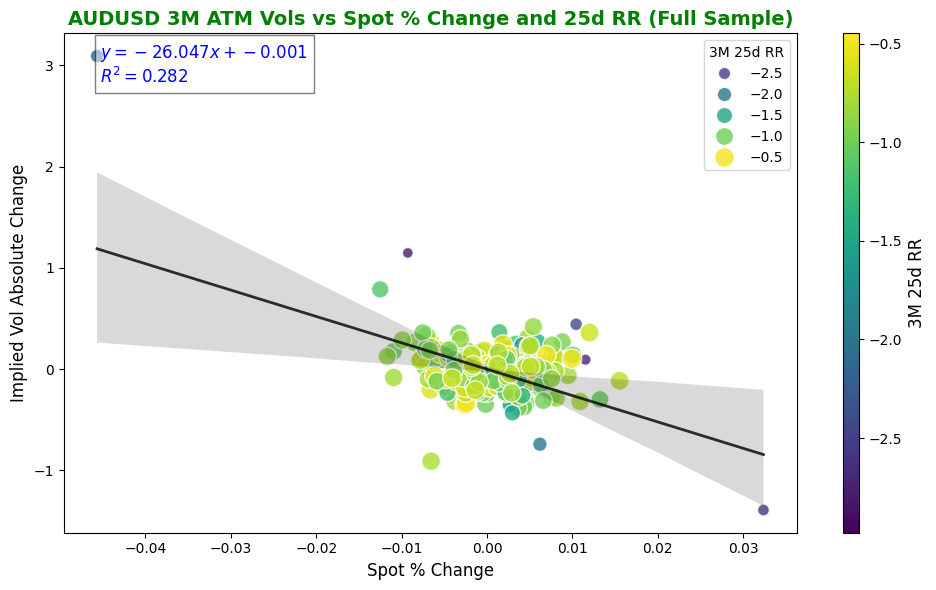

In [35]:
# -----------------------------
# Plot 1: Full sample (your original style)
# -----------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data,
    x='Spot % Change',
    y='Implied Vol Absolute Change',
    hue=f'{tenor} 25d RR',
    palette='viridis',
    size=f'{tenor} 25d RR',
    sizes=(50, 200),
    alpha=0.8
)

sns.regplot(
    data=plot_data,
    x='Spot % Change',
    y='Implied Vol Absolute Change',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2, 'alpha': 0.8}
)

eq_text = (
    f"$y = {model_full.params['Spot % Change']:.3f}x + {model_full.params['const']:.3f}$\n"
    f"$R^2 = {model_full.rsquared:.3f}$"
)
plt.text(
    0.05, 0.9, eq_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    color="blue",
    bbox=dict(facecolor='white', alpha=0.5)
)

plt.title(f'{ccy} {tenor} ATM Vols vs Spot % Change and 25d RR (Full Sample)',
          fontsize=14, fontweight='bold', color='green')
plt.xlabel('Spot % Change', fontsize=12)
plt.ylabel('Implied Vol Absolute Change', fontsize=12)

# Colorbar for RR (keeps your existing approach)
norm = plt.Normalize(plot_data[f'{tenor} 25d RR'].min(), plot_data[f'{tenor} 25d RR'].max())
sm_mappable = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm_mappable.set_array([])
cbar = plt.colorbar(sm_mappable, ax=plt.gca(), aspect=30)
cbar.set_label(f'{tenor} 25d RR', fontsize=12)

plt.tight_layout()
plt.show()

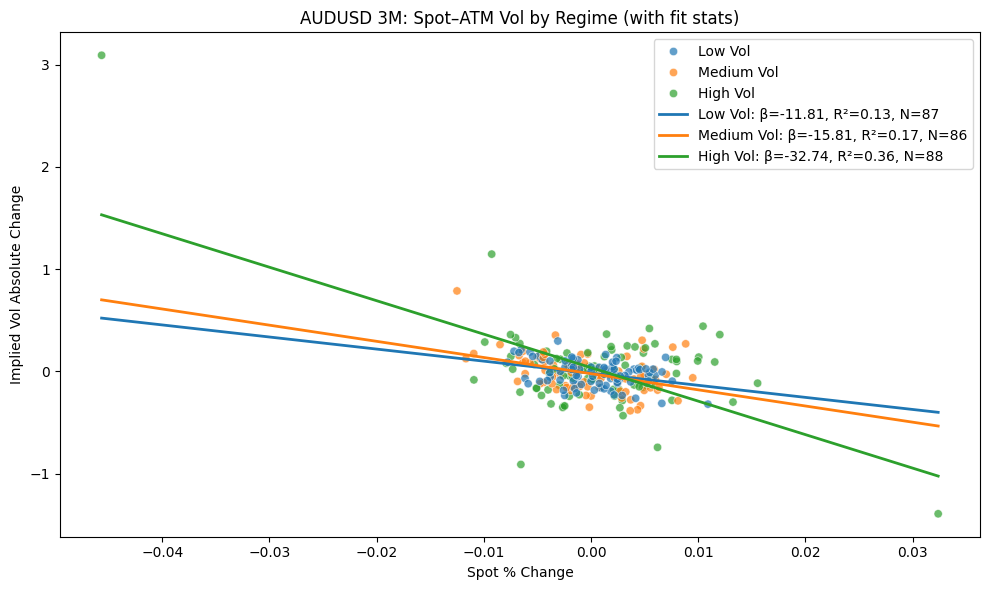

In [39]:
# -----------------------------
# Plot 2: Regime-split scatter + regime-specific regression lines
# -----------------------------
# (One chart, colored by regime; separate fitted line per regime)


plt.figure(figsize=(10, 6))

# scatter by regime
sns.scatterplot(
    data=plot_data,
    x='Spot % Change',
    y='Implied Vol Absolute Change',
    hue='Vol Regime',
    hue_order=regime_order,
    alpha=0.7
)

# add fitted line per regime with stats in label
x_global = np.linspace(plot_data['Spot % Change'].min(), plot_data['Spot % Change'].max(), 250)

for regime in regime_order:
    subset = plot_data[plot_data['Vol Regime'] == regime]
    if len(subset) < 10:
        continue

    X = sm.add_constant(subset['Spot % Change'])
    y = subset['Implied Vol Absolute Change']
    model = sm.OLS(y, X).fit()

    a = model.params['const']
    b = model.params['Spot % Change']
    r2 = model.rsquared
    n = int(model.nobs)

    plt.plot(
        x_global,
        a + b * x_global,
        linewidth=2,
        label=f"{regime}: β={b:.2f}, R²={r2:.2f}, N={n}"
    )

plt.title(f"{ccy} {tenor}: Spot–ATM Vol by Regime (with fit stats)")
plt.xlabel("Spot % Change")
plt.ylabel("Implied Vol Absolute Change")
plt.legend()
plt.tight_layout()
plt.show()

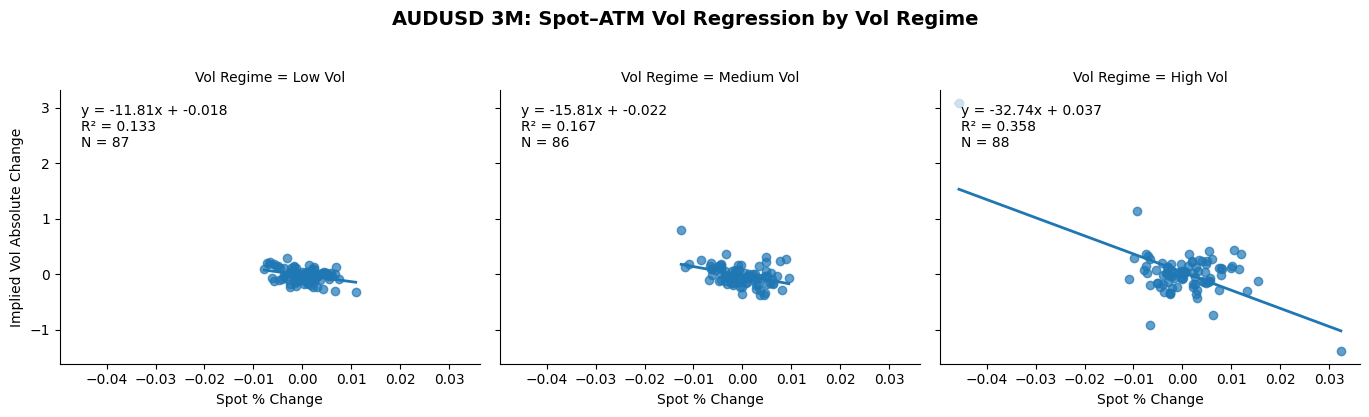

In [38]:
regime_order = ['Low Vol', 'Medium Vol', 'High Vol']

g = sns.FacetGrid(
    plot_data,
    col='Vol Regime',
    col_order=regime_order,
    height=4,
    aspect=1.15,
    sharex=True,
    sharey=True
)

def scatter_and_fit(data, **kws):
    ax = plt.gca()

    # scatter
    ax.scatter(
        data['Spot % Change'],
        data['Implied Vol Absolute Change'],
        alpha=0.7
    )

    # fit
    X = sm.add_constant(data['Spot % Change'])
    y = data['Implied Vol Absolute Change']
    model = sm.OLS(y, X).fit()

    a = model.params['const']
    b = model.params['Spot % Change']
    r2 = model.rsquared
    n = int(model.nobs)

    # line over the data range in this panel
    x_min, x_max = data['Spot % Change'].min(), data['Spot % Change'].max()
    x_grid = np.linspace(x_min, x_max, 200)
    ax.plot(x_grid, a + b * x_grid, linewidth=2)

    # annotation box
    txt = (
        f"y = {b:.2f}x + {a:.3f}\n"
        f"R² = {r2:.3f}\n"
        f"N = {n}"
    )
    ax.text(
        0.05, 0.95, txt,
        transform=ax.transAxes,
        va='top',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

g.map_dataframe(scatter_and_fit)

g.set_axis_labels("Spot % Change", "Implied Vol Absolute Change")
g.fig.suptitle(f"{ccy} {tenor}: Spot–ATM Vol Regression by Vol Regime", y=1.03, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()